<a href="https://colab.research.google.com/github/msemihyasa/Semih/blob/main/244329037_Mehmet_Semih_Yasa_VM_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Veri Madenciliğinde İleri Konular

Dersi Final Sınavı Ödevi 2025–2026 Güz Dönemi
Yüksek Lisans – Üsküdar Üniversitesi

244329037 - Mehmet Semih Yaşa


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/VM Final data.xlsx'

df = pd.read_excel(file_path)

# Veri temizleme: Model isimlerindeki küçük/büyük harf farklarını gider.
df['Model'] = df['Model'].str.capitalize()

print("Veri başarıyla yüklendi. İlk 5 satır:")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Veri başarıyla yüklendi. İlk 5 satır:


,ID,Kategori,Prompt (Soru),Model,Özet,Doğruluk,Halüsinasyon,Netlik (1-5),Yanıt (Text)
0,1,Yorumlama,Petkim'in son dönemdeki finansal performansını...,Gemini,Kârlılık Sorunu: Şirketin 3Ç25 gibi yakın döne...,True,Yok,5,"Görselde paylaştığınız soru, aslında şu ana ka..."
1,1,Yorumlama,Petkim'in son dönemdeki finansal performansını...,Chatgpt,Petkim şu anda finansal performansı zayıf ve k...,True,Yok,5,Aşağıda **Petkim’in (PETKM)** son dönemdeki fi...
2,2,Hesaplama,Petkim'in mevcut F/K oranı ve piyasa değeri üz...,Gemini,Petkim net zarar açıkladığı dönemlerde F/K ora...,Kısmen Doğru,Yok,4,"Görselde paylaştığınız ek sorular, Petkim anal..."
3,2,Hesaplama,Petkim'in mevcut F/K oranı ve piyasa değeri üz...,Chatgpt,• Petkim’in F/K (P/E) oranı son dönemde negati...,True,Yok,4,Aşağıda **Petkim’in mevcut fiyat‑kazanç (F/K) ...
4,3,Yorumlama,Petkim’in son 5 yıllık bilanço yapısını baz al...,Chatgpt,Özellik Petkim SASA Polyester Şişecam\nBorç/Öz...,True,Yok,5,Aşağıda **Petkim’in son 5 yıllık bilanço yapıs...


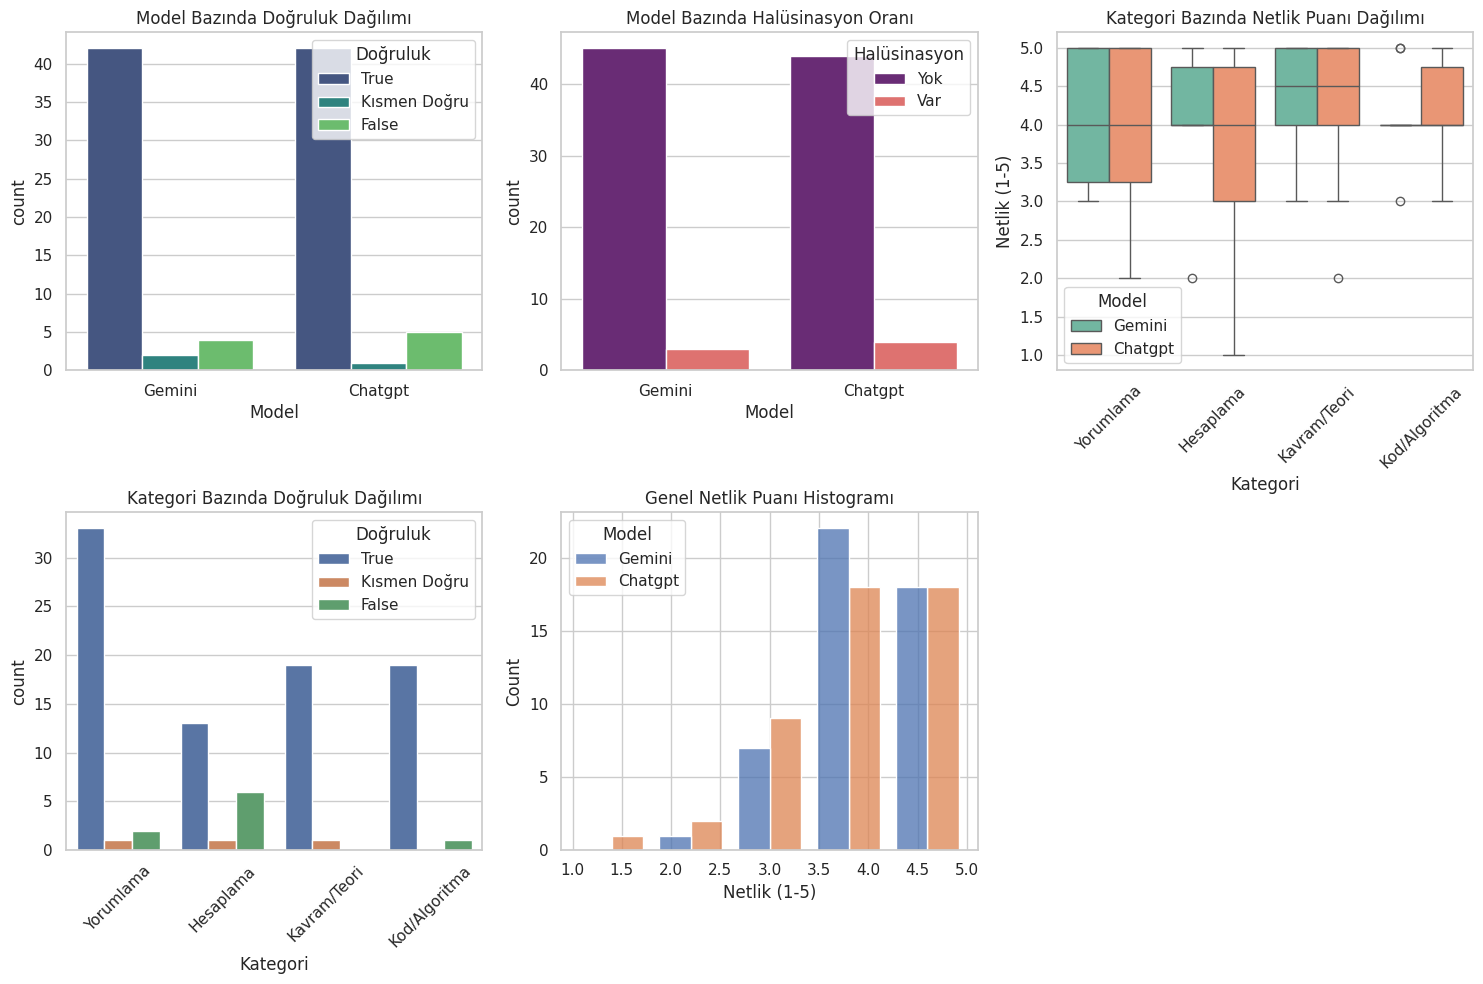

In [ ]:
# Grafik boyutunu ve temasını ayarla
plt.figure(figsize=(15, 10))
sns.set_theme(style="whitegrid")

# 1. Model Bazında Doğruluk Dağılımı
plt.subplot(2, 3, 1)
sns.countplot(data=df, x='Model', hue='Doğruluk', palette='viridis')
plt.title('Model Bazında Doğruluk Dağılımı')

# 2. Model Bazında Halüsinasyon Varlığı
plt.subplot(2, 3, 2)
sns.countplot(data=df, x='Model', hue='Halüsinasyon', palette='magma')
plt.title('Model Bazında Halüsinasyon Oranı')

# 3. Kategori Bazında Netlik Dağılımı
plt.subplot(2, 3, 3)
sns.boxplot(data=df, x='Kategori', y='Netlik (1-5)', hue='Model', palette='Set2')
plt.title('Kategori Bazında Netlik Puanı Dağılımı')
plt.xticks(rotation=45)

# 4. Kategori Bazında Doğruluk Karşılaştırması
plt.subplot(2, 3, 4)
sns.countplot(data=df, x='Kategori', hue='Doğruluk')
plt.title('Kategori Bazında Doğruluk Dağılımı')
plt.xticks(rotation=45)

# 5. Netlik Puanı Genel Dağılımı
plt.subplot(2, 3, 5)
sns.histplot(data=df, x='Netlik (1-5)', hue='Model', multiple="dodge", shrink=.8, bins=5)
plt.title('Genel Netlik Puanı Histogramı')

plt.tight_layout()
plt.show()

In [ ]:
print("--- Model Bazında Ortalama Netlik Puanları ---")
print(df.groupby('Model')['Netlik (1-5)'].mean())

print("\n--- Kategori ve Model Bazında Halüsinasyon Sayıları ---")
hallucination_summary = pd.crosstab([df['Kategori'], df['Model']], df['Halüsinasyon'])
print(hallucination_summary)

print("\n--- Genel Doğruluk Oranları (%) ---")
accuracy_pct = df.groupby('Model')['Doğruluk'].value_counts(normalize=True) * 100
print(accuracy_pct)

--- Model Bazında Ortalama Netlik Puanları ---
Model
Chatgpt    4.041667
Gemini     4.187500
Name: Netlik (1-5), dtype: float64

--- Kategori ve Model Bazında Halüsinasyon Sayıları ---
Halüsinasyon           Var  Yok
Kategori      Model            
Hesaplama     Chatgpt    3    7
              Gemini     2    8
Kavram/Teori  Chatgpt    0   10
              Gemini     0   10
Kod/Algoritma Chatgpt    0   10
              Gemini     0   10
Yorumlama     Chatgpt    1   17
              Gemini     1   17

--- Genel Doğruluk Oranları (%) ---
Model    Doğruluk    
Chatgpt  True            87.500000
         False           10.416667
         Kısmen Doğru     2.083333
Gemini   True            87.500000
         False            8.333333
         Kısmen Doğru     4.166667
Name: proportion, dtype: float64


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# 1. Veri Hazırlığı ve Temizleme
df['Halüsinasyon'] = df['Halüsinasyon'].astype(str).str.lower().str.strip()
df['Doğruluk'] = df['Doğruluk'].astype(str).str.lower().str.strip()

# 2. Feature Engineering
df['Metin_Uzunlugu'] = df['Yanıt (Text)'].apply(len)
df['Kelime_Sayisi'] = df['Yanıt (Text)'].apply(lambda x: len(x.split()))

# Label Encoding
le_model = LabelEncoder()
df['Model_Encoded'] = le_model.fit_transform(df['Model'])

le_kategori = LabelEncoder()
df['Kategori_Encoded'] = le_kategori.fit_transform(df['Kategori'])

# 3. Metin Madenciliği (TF-IDF)
# Yanıt metinlerini kelime ağırlıklarına göre vektörlere çevirme
tfidf = TfidfVectorizer(max_features=100, stop_words=None)
text_features = tfidf.fit_transform(df['Yanıt (Text)']).toarray()

# Tüm özellikleri birleştirme
X = np.hstack((text_features,
               df[['Metin_Uzunlugu', 'Kelime_Sayisi', 'Model_Encoded', 'Kategori_Encoded']].values))

# Hedef değişken: Halüsinasyon (Var/Yok)
y = LabelEncoder().fit_transform(df['Halüsinasyon'])

# 4. Eğitim ve Test Setine Ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Yöntem 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# 6. Yöntem 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# 7. Metriklerin Karşılaştırılması
print("=== LOGISTIC REGRESSION SONUÇLARI ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== RANDOM FOREST SONUÇLARI ===")
print(classification_report(y_test, y_pred_rf))

print(f"\nNetlik Tahmini için Örnek MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")

=== LOGISTIC REGRESSION SONUÇLARI ===
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.95      1.00      0.97        18

    accuracy                           0.95        20
   macro avg       0.97      0.75      0.82        20
weighted avg       0.95      0.95      0.94        20


=== RANDOM FOREST SONUÇLARI ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20


Netlik Tahmini için Örnek MAE: 0.10


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from google.colab import drive


df_classification = df.copy()

# 1. Veri Hazırlığı ve Temizleme

df_classification['Halüsinasyon'] = df_classification['Halüsinasyon'].astype(str).str.lower().str.strip()
df_classification['Doğruluk'] = df_classification['Doğruluk'].astype(str).str.lower().str.strip()

print("Adım 1: .astype(str).str.lower().str.strip() sonrası Doğruluk değerleri:")
display(df_classification['Doğruluk'].value_counts())

# 'true' -> 'doğru' and 'false' -> 'yanlış'
df_classification['Doğruluk'] = df_classification['Doğruluk'].replace({'true': 'doğru', 'false': 'yanlış'})

print("Adım 2: replace sonrası Doğruluk değerleri:")
display(df_classification['Doğruluk'].value_counts())

valid_doğruluk_labels = ['doğru', 'yanlış', 'kısmen doğru']
df_classification = df_classification[df_classification['Doğruluk'].isin(valid_doğruluk_labels)]

print("Adım 3: valid_doğruluk_labels ile filtreleme sonrası Doğruluk değerleri:")
display(df_classification['Doğruluk'].value_counts())

df_classification['Yanıt (Text)'] = df_classification['Yanıt (Text)'].fillna('')

# 2. Feature Engineering
df_classification['Metin_Uzunlugu'] = df_classification['Yanıt (Text)'].apply(len)
df_classification['Kelime_Sayisi'] = df_classification['Yanıt (Text)'].apply(lambda x: len(x.split()))


# Kategorik sütunları sayısallaştırma
le_model = LabelEncoder()
df_classification['Model_Encoded'] = le_model.fit_transform(df_classification['Model'].str.capitalize())

le_kategori = LabelEncoder()
df_classification['Kategori_Encoded'] = le_kategori.fit_transform(df_classification['Kategori'])

# 3. Metin Madenciliği (TF-IDF)
# Yanıt metinlerini kelime ağırlıklarına göre vektörlere çevirme
tfidf = TfidfVectorizer(max_features=200, stop_words=None)
text_features = tfidf.fit_transform(df_classification['Yanıt (Text)']).toarray()

# Sayısal özellikleri ve metin özelliklerini birleştirme
X = np.hstack((text_features,
               df_classification[['Metin_Uzunlugu', 'Kelime_Sayisi', 'Model_Encoded', 'Kategori_Encoded']].values))

# Hedef Değişken: Doğruluk
le_target = LabelEncoder()
y = le_target.fit_transform(df_classification['Doğruluk'])

# Eğitim ve Test Setine Ayırma
if len(np.unique(y)) < 2:
    print("Warning: Not enough classes to perform stratified split. Skipping classification.")
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Model 1: Logistic Regression
    lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)

    #  Model 2: Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    #  Sonuçların Raporlanması
    print("--- DOĞRULUK SINIFLANDIRMA ANALİZİ ---")
    print("\n[YÖNTEM 1: LOGISTIC REGRESSION]")
    print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))

    print("\n[YÖNTEM 2: RANDOM FOREST]")
    print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

Adım 1: .astype(str).str.lower().str.strip() sonrası Doğruluk değerleri:


,count
Doğruluk,
true,84
false,9
kısmen doğru,3


Adım 2: replace sonrası Doğruluk değerleri:


,count
Doğruluk,
doğru,84
yanlış,9
kısmen doğru,3


Adım 3: valid_doğruluk_labels ile filtreleme sonrası Doğruluk değerleri:


,count
Doğruluk,
doğru,84
yanlış,9
kısmen doğru,3


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- DOĞRULUK SINIFLANDIRMA ANALİZİ ---

[YÖNTEM 1: LOGISTIC REGRESSION]
              precision    recall  f1-score   support

       doğru       0.88      0.82      0.85        17
kısmen doğru       0.00      0.00      0.00         1
      yanlış       0.33      0.50      0.40         2

    accuracy                           0.75        20
   macro avg       0.40      0.44      0.42        20
weighted avg       0.78      0.75      0.76        20


[YÖNTEM 2: RANDOM FOREST]
              precision    recall  f1-score   support

       doğru       0.85      1.00      0.92        17
kısmen doğru       0.00      0.00      0.00         1
      yanlış       0.00      0.00      0.00         2

    accuracy                           0.85        20
   macro avg       0.28      0.33      0.31        20
weighted avg       0.72      0.85      0.78        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Hedef Değişkeni Belirleme (Netlik)
y_netlik = df['Netlik (1-5)']

# 2. Eğitim ve Test Setine Ayırma
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X, y_netlik, test_size=0.2, random_state=42)

# 3. Yöntem 1: Linear Regression (Doğrusal Regresyon)
lr_regressor = LinearRegression()
lr_regressor.fit(X_train_n, y_train_n)
y_pred_lr_n = lr_regressor.predict(X_test_n)

# 4. Yöntem 2: Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_n, y_train_n)
y_pred_rf_n = rf_regressor.predict(X_test_n)

# 5. MAE ve Diğer Metriklerin Hesaplanması
mae_lr = mean_absolute_error(y_test_n, y_pred_lr_n)
mae_rf = mean_absolute_error(y_test_n, y_pred_rf_n)
rmse_rf = np.sqrt(mean_squared_error(y_test_n, y_pred_rf_n))

print("=== NETLİK TAHMİNLEME PERFORMANSI (MAE) ===")
print(f"Linear Regression MAE : {mae_lr:.4f}")
print(f"Random Forest MAE     : {mae_rf:.4f}")
print(f"Random Forest RMSE    : {rmse_rf:.4f}")

# Sonuçları Karşılaştırmalı Gösterim
results_df = pd.DataFrame({
    'Gerçek Değer': y_test_n.values,
    'LR Tahmini': np.round(y_pred_lr_n, 1),
    'RF Tahmini': np.round(y_pred_rf_n, 1)
})
print("\n---Test Tahmini Karşılaştırması ---")
print(results_df)

=== NETLİK TAHMİNLEME PERFORMANSI (MAE) ===
Linear Regression MAE : 1.4913
Random Forest MAE     : 0.9115
Random Forest RMSE    : 1.0342

---Test Tahmini Karşılaştırması ---
    Gerçek Değer  LR Tahmini  RF Tahmini
0              4         5.3         4.3
1              4         4.0         4.2
2              3         4.5         3.9
3              5         3.4         4.3
4              2         5.5         3.9
5              4         3.2         3.4
6              5         3.1         3.8
7              3         5.1         4.7
8              5         3.9         4.1
9              5         1.7         4.1
10             4         3.4         4.1
11             5         2.8         3.6
12             3         3.6         4.6
13             5         2.8         4.1
14             4         5.6         3.0
15             5         3.2         4.1
16             5         3.0         3.8
17             4         5.1         4.3
18             4         4.3         4.4
19    

In [ ]:
df = pd.read_excel(file_path)

df['Model'] = df['Model'].str.capitalize()

print("Veri başarıyla yeniden yüklendi. İlk 5 satır:")
display(df.head())

df_classification = df.copy()

df_classification['Doğruluk'] = df_classification['Doğruluk'].replace({True: 'doğru', False: 'yanlış'})

df_classification['Doğruluk'] = df_classification['Doğruluk'].astype(str).str.lower().str.strip()

print("\nAdım 1 (Yeniden Yükleme Sonrası): Temizleme sonrası Doğruluk değerleri:")
display(df_classification['Doğruluk'].value_counts(dropna=False))

valid_doğruluk_labels = ['doğru', 'yanlış', 'kısmen doğru']
df_classification = df_classification[df_classification['Doğruluk'].isin(valid_doğruluk_labels)]

print("\nAdım 2 (Yeniden Yükleme Sonrası): valid_doğruluk_labels ile filtreleme sonrası Doğruluk değerleri:")
display(df_classification['Doğruluk'].value_counts(dropna=False))

df_classification['Doğruluk_Binary'] = df_classification['Doğruluk'].replace({'kısmen doğru': 'yanlış'})

print("\nAdım 3 (Yeniden Yükleme Sonrası): 'kısmen doğru' -> 'yanlış' dönüşümü sonrası Doğruluk_Binary değerleri:")
display(df_classification['Doğruluk_Binary'].value_counts(dropna=False))

Veri başarıyla yeniden yüklendi. İlk 5 satır:


,ID,Kategori,Prompt (Soru),Model,Özet,Doğruluk,Halüsinasyon,Netlik (1-5),Yanıt (Text)
0,1,Yorumlama,Petkim'in son dönemdeki finansal performansını...,Gemini,Kârlılık Sorunu: Şirketin 3Ç25 gibi yakın döne...,True,Yok,5,"Görselde paylaştığınız soru, aslında şu ana ka..."
1,1,Yorumlama,Petkim'in son dönemdeki finansal performansını...,Chatgpt,Petkim şu anda finansal performansı zayıf ve k...,True,Yok,5,Aşağıda **Petkim’in (PETKM)** son dönemdeki fi...
2,2,Hesaplama,Petkim'in mevcut F/K oranı ve piyasa değeri üz...,Gemini,Petkim net zarar açıkladığı dönemlerde F/K ora...,Kısmen Doğru,Yok,4,"Görselde paylaştığınız ek sorular, Petkim anal..."
3,2,Hesaplama,Petkim'in mevcut F/K oranı ve piyasa değeri üz...,Chatgpt,• Petkim’in F/K (P/E) oranı son dönemde negati...,True,Yok,4,Aşağıda **Petkim’in mevcut fiyat‑kazanç (F/K) ...
4,3,Yorumlama,Petkim’in son 5 yıllık bilanço yapısını baz al...,Chatgpt,Özellik Petkim SASA Polyester Şişecam\nBorç/Öz...,True,Yok,5,Aşağıda **Petkim’in son 5 yıllık bilanço yapıs...



Adım 1 (Yeniden Yükleme Sonrası): Temizleme sonrası Doğruluk değerleri:


,count
Doğruluk,
doğru,84
yanlış,9
kısmen doğru,3



Adım 2 (Yeniden Yükleme Sonrası): valid_doğruluk_labels ile filtreleme sonrası Doğruluk değerleri:


,count
Doğruluk,
doğru,84
yanlış,9
kısmen doğru,3



Adım 3 (Yeniden Yükleme Sonrası): 'kısmen doğru' -> 'yanlış' dönüşümü sonrası Doğruluk_Binary değerleri:


,count
Doğruluk_Binary,
doğru,84
yanlış,12


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import LabelEncoder


df_classification['Yanıt (Text)'] = df_classification['Yanıt (Text)'].fillna('')


df_classification['Metin_Uzunlugu'] = df_classification['Yanıt (Text)'].apply(len)
df_classification['Kelime_Sayisi'] = df_classification['Yanıt (Text)'].apply(lambda x: len(x.split()))

le_model = LabelEncoder()
df_classification['Model_Encoded'] = le_model.fit_transform(df_classification['Model'].str.capitalize())

le_kategori = LabelEncoder()
df_classification['Kategori_Encoded'] = le_kategori.fit_transform(df_classification['Kategori'])

tfidf = TfidfVectorizer(max_features=200, stop_words=None)
text_features = tfidf.fit_transform(df_classification['Yanıt (Text)']).toarray()

X = np.hstack((text_features,
               df_classification[['Metin_Uzunlugu', 'Kelime_Sayisi', 'Model_Encoded', 'Kategori_Encoded']].values))

le_target = LabelEncoder()
y = le_target.fit_transform(df_classification['Doğruluk_Binary'])

print("Features ve hedef değişken başarıyla hazırlandı.")

Features and target variable prepared successfully.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Sonuçların Raporlanması
print("--- DOĞRULUK SINIFLANDIRMA ANALİZİ ---")
print("\n[YÖNTEM 1: LOGISTIC REGRESSION]")
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_, zero_division=0))

print("\n[YÖNTEM 2: RANDOM FOREST]")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_, zero_division=0))

--- DOĞRULUK SINIFLANDIRMA ANALİZİ ---

[YÖNTEM 1: LOGISTIC REGRESSION]
              precision    recall  f1-score   support

       doğru       0.94      0.94      0.94        18
      yanlış       0.50      0.50      0.50         2

    accuracy                           0.90        20
   macro avg       0.72      0.72      0.72        20
weighted avg       0.90      0.90      0.90        20


[YÖNTEM 2: RANDOM FOREST]
              precision    recall  f1-score   support

       doğru       0.90      1.00      0.95        18
      yanlış       0.00      0.00      0.00         2

    accuracy                           0.90        20
   macro avg       0.45      0.50      0.47        20
weighted avg       0.81      0.90      0.85        20

